# Harmonisasi & Pengambilan Irisan 3 Kelas (Multiclass)
## Penggabungan Terpadu: HAM10000 ∩ ISIC 2017 ∩ ISIC 2019

Notebook ini mengimplementasikan alur **Jalur Irisan 3 Kelas** sesuai rancangan metodologi diagram `plan.text`.
Dengan menggabungkan 3 dataset dermatologi internasional (**HAM10000**, **ISIC 2017**, dan **ISIC 2019**), proses pengambilan irisan persekutuan (*intersection*) secara objektif menghasilkan **3 KELAS DIAGNOSIS INTI**:
1. **`NV` (Melanocytic Nevus):** Tahi lalat jinak melanositik
2. **`MEL` (Melanoma):** Kanker kulit ganas melanosit
3. **`BKL` (Benign Keratosis):** Keratosis seboroik / lentigo surya jinak

### Rujukan Ilmiah & Landasan Medis Terkait:
* **Codella et al. (IEEE ISBI 2018):** Standar benchmark resmi klasifikasi lesi kulit 3 kelas (Task 3: Melanoma vs Seborrheic Keratosis vs Benign Nevi).
* **Tschandl et al. (Nature Scientific Data 2018):** Definisi klinis patologis HAM10000, ontologi resmi bahwa kategori BKL memayungi seborrheic keratosis, dan mitigasi kebocoran lesi pasien.
* **Ternov et al. (JEADV Clinical Practice 2022) / Combalia et al. (2019):** Karakteristik 25.331 citra ISIC 2019, penegasan terminologi Benign Keratinocytic Lesions (BKL), dan justifikasi penggabungan multi-dataset untuk mengatasi bias domain-shift.
* **Ichim et al. (MDPI Cancers 2023):** Protokol pembersihan duplikasi (*overlap removal*) antar-arsip dataset ISIC guna mencegah bias evaluasi data leakage.


## Langkah 1 — Setup Library, Konfigurasi Path, & 3 Dataset Pilihan
Menyiapkan pustaka pengolahan data, mendeteksi direktori `Dataset/`, dan mendefinisikan konfigurasi 3 sumber data: HAM10000, ISIC 2017 (Train/Val/Test), dan ISIC 2019 Training Data.


In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
from IPython.display import display

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = 'Arial'

# Deteksi root folder dataset secara adaptif
folder_aktif = os.getcwd()
if os.path.exists(os.path.join(folder_aktif, 'Dataset')):
    ROOT = os.path.join(folder_aktif, 'Dataset')
elif os.path.exists(os.path.join(os.path.dirname(folder_aktif), 'Dataset')):
    ROOT = os.path.join(os.path.dirname(folder_aktif), 'Dataset')
else:
    ROOT = r"C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset"

print(f"Folder Dataset Aktif: {ROOT}")

# Konfigurasi 3 Sumber Dataset Pilihan
SOURCES = {
    'ham10000': {
        'nama': 'HAM10000 (ViDIR Austria & Queensland Australia)',
        'img_dirs': [
            os.path.join(ROOT, 'HAM10K', 'HAM10000_images_part_1'),
            os.path.join(ROOT, 'HAM10K', 'HAM10000_images_part_2'),
        ],
        'gt_path': os.path.join(ROOT, 'HAM10K', 'HAM10000_metadata'),
        'fmt': 'ham_dx'
    },
    'isic_2019_train': {
        'nama': 'ISIC 2019 Training Input (BCN-20000 + ViDIR + HAM10k Overlap)',
        'img_dir': os.path.join(ROOT, 'isic 2019', 'ISIC_2019_Training_Input', 'ISIC_2019_Training_Input'),
        'gt_path': os.path.join(ROOT, 'isic 2019', 'ISIC_2019_Training_Input', 'ISIC_2019_Training_GroundTruth.csv'),
        'fmt': 'onehot9'
    },
    'isic_2017_train': {
        'nama': 'ISIC 2017 Training Data',
        'img_dir': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Training_Data', 'ISIC-2017_Training_Data'),
        'gt_path': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Training_Data', 'ISIC-2017_Training_Part3_GroundTruth.csv'),
        'fmt': '2017'
    },
    'isic_2017_val': {
        'nama': 'ISIC 2017 Validation Data',
        'img_dir': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Validation_Data', 'ISIC-2017_Validation_Data'),
        'gt_path': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Validation_Data', 'ISIC-2017_Validation_Part3_GroundTruth.csv'),
        'fmt': '2017'
    },
    'isic_2017_test': {
        'nama': 'ISIC 2017 Test Data (v2)',
        'img_dir': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Test_v2_Data', 'ISIC-2017_Test_v2_Data'),
        'gt_path': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Test_v2_Data', 'ISIC-2017_Test_v2_Part3_GroundTruth.csv'),
        'fmt': '2017'
    }
}

for k, v in SOURCES.items():
    print(f"[*] {k}: {v['nama']}")


Folder Dataset Aktif: C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset
[*] ham10000: HAM10000 (ViDIR Austria & Queensland Australia)
[*] isic_2019_train: ISIC 2019 Training Input (BCN-20000 + ViDIR + HAM10k Overlap)
[*] isic_2017_train: ISIC 2017 Training Data
[*] isic_2017_val: ISIC 2017 Validation Data
[*] isic_2017_test: ISIC 2017 Test Data (v2)


## Langkah 2 — Pemindaian Citra Fisik & Pembacaan Ground Truth Asli
Memindai seluruh file gambar (.jpg / .jpeg) dan membaca ground truth masing-masing sumber secara independen untuk menjaga keaslian label bawaan tiap dataset.


In [2]:
# 1. Pindai seluruh citra fisik
IMG_EXT = ('.jpg', '.jpeg')
all_images = []

for source, info in SOURCES.items():
    if 'img_dirs' in info:
        for d in info['img_dirs']:
            if os.path.exists(d):
                for f in os.listdir(d):
                    if f.lower().endswith(IMG_EXT):
                        all_images.append({
                            'image_id': os.path.splitext(f)[0],
                            'source': source,
                            'filepath': os.path.join(d, f)
                        })
    else:
        d = info.get('img_dir')
        if d and os.path.exists(d):
            for root_dir, _, files in os.walk(d):
                if '__MACOSX' in root_dir:
                    continue
                for f in files:
                    if f.lower().endswith(IMG_EXT) and not f.startswith('._'):
                        all_images.append({
                            'image_id': os.path.splitext(f)[0],
                            'source': source,
                            'filepath': os.path.join(root_dir, f)
                        })

df_images = pd.DataFrame(all_images)

# 2. Muat Ground Truth masing-masing sumber secara terpisah
gt_records = {}

# HAM10000
df_ham = pd.read_csv(SOURCES['ham10000']['gt_path'])
gt_records['ham10000'] = dict(zip(df_ham['image_id'], df_ham['dx'].str.lower()))

# ISIC 2019
df_19 = pd.read_csv(SOURCES['isic_2019_train']['gt_path'])
cols_19 = [c for c in df_19.columns if c not in ('image', 'score_weight', 'validation_weight')]
gt_19 = {}
for _, r in df_19.iterrows():
    for c in cols_19:
        if r[c] == 1.0:
            gt_19[r['image']] = c  # Pertahankan huruf kapital asli dari kolom CSV ISIC 2019
            break
gt_records['isic_2019_train'] = gt_19

# ISIC 2017 (Train, Val, Test)
for s in ['isic_2017_train', 'isic_2017_val', 'isic_2017_test']:
    df_17 = pd.read_csv(SOURCES[s]['gt_path'])
    id_col = 'image_id' if 'image_id' in df_17.columns else df_17.columns[0]
    gt_17 = {}
    for _, r in df_17.iterrows():
        img_id = str(r[id_col]).replace('.jpg', '')
        if r.get('melanoma') == 1.0:
            gt_17[img_id] = 'melanoma'
        elif r.get('seborrheic_keratosis') == 1.0:
            gt_17[img_id] = 'seborrheic_keratosis'
        else:
            gt_17[img_id] = 'nevus'
    gt_records[s] = gt_17

# Pasangkan label sesuai (source, image_id)
df_images['original_label'] = df_images.apply(
    lambda r: gt_records.get(r['source'], {}).get(r['image_id'], np.nan), axis=1
)

print(f"Total citra fisik terindeks dari seluruh sumber: {len(df_images):,} citra")
for src in SOURCES.keys():
    sub = df_images[df_images['source'] == src]
    print(f"  - {src}: {len(sub):,} citra fisik ({sub['original_label'].notna().sum():,} memiliki label)")


Total citra fisik terindeks dari seluruh sumber: 38,096 citra
  - ham10000: 10,015 citra fisik (10,015 memiliki label)
  - isic_2019_train: 25,331 citra fisik (25,331 memiliki label)
  - isic_2017_train: 2,000 citra fisik (2,000 memiliki label)
  - isic_2017_val: 150 citra fisik (150 memiliki label)
  - isic_2017_test: 600 citra fisik (600 memiliki label)


## Langkah 3 — Deduplikasi Terarah (HAM10000 Prioritas 100% Utuh)
Protokol deduplikasi bertingkat:
1. HAM10000 dipertahankan 100% utuh (**10.015 citra**).
2. Duplikat identik pada ISIC 2019 dieliminasi (10.015 citra dibuang, menyisakan 15.316 citra baru).
3. Duplikat identik pada ISIC 2017 dieliminasi terhadap data yang sudah ada sebelumnya.


In [3]:
PRIORITY_ORDER = [
    'ham10000',
    'isic_2019_train',
    'isic_2017_train',
    'isic_2017_val',
    'isic_2017_test'
]
priority_rank = {src: i for i, src in enumerate(PRIORITY_ORDER)}

df_all = df_images.copy()
df_all['priority'] = df_all['source'].map(priority_rank)

# Urutkan berdasarkan prioritas dan buang duplikat image_id
df_sorted = df_all.sort_values(by=['image_id', 'priority'])
df_clean = df_sorted.drop_duplicates(subset='image_id', keep='first').copy()
df_dropped = df_sorted[~df_sorted.index.isin(df_clean.index)].copy()

# Petakan duplikat disimpan di mana
kept_map = df_clean.set_index('image_id')['source'].to_dict()
df_dropped['kept_in_source'] = df_dropped['image_id'].map(kept_map)

# Tabel Before vs After Deduplikasi
before_counts = df_all['source'].value_counts()
after_counts = df_clean['source'].value_counts()
dropped_counts = df_dropped['source'].value_counts()

rows_ba = []
for src in PRIORITY_ORDER:
    b = before_counts.get(src, 0)
    a = after_counts.get(src, 0)
    d = dropped_counts.get(src, 0)
    pct_drop = round((d / b * 100), 2) if b > 0 else 0
    
    dropped_src = df_dropped[df_dropped['source'] == src]
    if len(dropped_src) > 0:
        kept_counts = dropped_src['kept_in_source'].value_counts()
        detail_kept = "; ".join([f"{k} ({v:,} citra)" for k, v in kept_counts.items()])
    else:
        detail_kept = "-"
        
    rows_ba.append({
        'Source Dataset': src,
        'Before (Awal)': f"{b:,}",
        'Duplikat Dihapus': f"{d:,}",
        'After (Bersih Unik)': f"{a:,}",
        '% Reduksi': f"{pct_drop}%",
        'Keterangan Deduplikasi': detail_kept
    })

df_ba_table = pd.DataFrame(rows_ba)
print("=== TABEL BEFORE vs AFTER DEDUPLIKASI (HAM10000 PRIORITAS 100%) ===")
display(df_ba_table)

print(f"\nTotal citra awal             : {len(df_all):,} citra")
print(f"Total duplikat tumpang tindih: {len(df_dropped):,} citra")
print(f"Total citra unik bersih      : {len(df_clean):,} citra")


=== TABEL BEFORE vs AFTER DEDUPLIKASI (HAM10000 PRIORITAS 100%) ===


,Source Dataset,Before (Awal),Duplikat Dihapus,After (Bersih Unik),% Reduksi,Keterangan Deduplikasi
0,ham10000,"10,015",0,"10,015",0.0%,-
1,isic_2019_train,"25,331","10,015","15,316",39.54%,"ham10000 (10,015 citra)"
2,isic_2017_train,"2,000",717,"1,283",35.85%,isic_2019_train (717 citra)
3,isic_2017_val,150,2,148,1.33%,isic_2019_train (2 citra)
4,isic_2017_test,600,1,599,0.17%,isic_2019_train (1 citra)



Total citra awal             : 38,096 citra
Total duplikat tumpang tindih: 10,735 citra
Total citra unik bersih      : 27,361 citra


## Langkah 4 — Analisis Komparasi Label & Harmonisasi Sinonim Medis

Berdasarkan rancangan alur diagram `plan.text`, tahap ini menjalankan:
1. **Bandingkan label antar-dataset:** Mengidentifikasi nama kolom dan singkatan label bawaan masing-masing arsip.
2. **Verifikasi definisi diagnosis medis:** Meneliti literatur patologi dermatologi untuk membuktikan kesetaraan biologis antar-istilah.
3. **Harmonisasi etiket diagnosis:** Menyelaraskan seluruh variasi penamaan ke dalam satu format kanonikal standar bersama:
   * `benign nevi` (ISIC 2017) dan `nv` (HAM10k / ISIC 2019) $\rightarrow$ **`NV`** (*Melanocytic Nevus*)
   * `melanoma` (ISIC 2017) dan `mel` (HAM10k / ISIC 2019) $\rightarrow$ **`MEL`** (*Melanoma*)
   * `seborrheic_keratosis` (ISIC 2017) dan `bkl` (HAM10k / ISIC 2019) $\rightarrow$ **`BKL`** (*Benign Keratosis*)

> 🩺 **Bukti Emas Medis Harmonisasi BKL $\equiv$ Seborrheic Keratosis (Tschandl et al., Nature 2018):**
> *"Benign keratosis is a generic class that includes **seborrheic keratoses** ('senile wart'), **solar lentigo**... and **lichen-planus like keratoses (LPLK)**... The three subgroups may look different dermatoscopically, but we grouped them together because they are **similar biologically and often reported under the same generic term histopathologically**."*
>
> Selain itu, **Ternov et al. (JEADV 2022)** mengonfirmasi secara formal kepanjangan `BKL` sebagai *"Benign Keratinocytic Lesions"*. Seborrheic keratosis secara histopatologis merupakan tumor proliferasi sel keratinosit epidermis jinak. Karena lesi BKL kerap menunjukkan gambaran klinis meniru melanoma (*melanoma mimicker*), klasifikasi diferensial antara MEL dan BKL adalah prioritas diagnostik dokter spesialis kulit sedunia.

> 📌 **Justifikasi Eliminasi 5 Kelas Non-Irisan:**
> Kompetisi ISIC 2017 Task 3 (Codella et al., 2018) hanya mendefinisikan 3 kelas target (`NV`, `MEL`, `BKL`). Kategori karsinoma sel basal (`BCC`), pra-kanker (`AKIEC`), karsinoma sel skuamosa (`SCC`), lesi vaskular (`VASC`), dan dermatofibroma (`DF`) tidak memiliki anotasi pada ISIC 2017. Sesuai prinsip irisan bersama $(A \cap B \cap C)$, kelima kelas tersebut dieksklusi secara objektif agar integritas dataset tetap seimbang tanpa adanya nilai hilang (*missing labels*).


In [4]:
HARMONIZATION_MAP = {
    # HAM10000 (huruf kecil asli dari kolom dx)
    'nv': 'NV', 'mel': 'MEL', 'bkl': 'BKL', 'bcc': 'BCC',
    'akiec': 'AKIEC', 'vasc': 'VASC', 'df': 'DF',
    # ISIC 2017 (kata lengkap asli dari Part 3 Ground Truth)
    'nevus': 'NV', 'melanoma': 'MEL', 'seborrheic_keratosis': 'BKL',
    # ISIC 2019 (huruf kapital asli dari kolom Ground Truth CSV)
    'NV': 'NV', 'MEL': 'MEL', 'BKL': 'BKL', 'BCC': 'BCC',
    'AK': 'AKIEC', 'SCC': 'SCC', 'VASC': 'VASC', 'DF': 'DF'
}

MED_DESC = {
    'NV': ('Melanocytic Nevus', 'Tahi lalat jinak melanositik'),
    'MEL': ('Melanoma', 'Kanker kulit ganas melanosit'),
    'BKL': ('Benign Keratosis', 'Keratosis seboroik / lentigo surya jinak'),
    'BCC': ('Basal Cell Carcinoma', 'Karsinoma sel basal ganas'),
    'AKIEC': ('Actinic Keratosis', 'Lesi pra-kanker keratinositik'),
    'VASC': ('Vascular Lesion', 'Kelainan pembuluh darah kulit jinak'),
    'DF': ('Dermatofibroma', 'Nodul jinak jaringan ikat fibrohistiositik'),
    'SCC': ('Squamous Cell Carcinoma', 'Karsinoma sel skuamosa ganas')
}

df_clean['harmonized_label'] = df_clean['original_label'].map(HARMONIZATION_MAP)

# Ringkasan cakupan label per dataset
harm_summary = []
for code, (med_name, desc) in MED_DESC.items():
    cnt_ham = len(df_clean[(df_clean['source'] == 'ham10000') & (df_clean['harmonized_label'] == code)])
    cnt_19 = len(df_clean[(df_clean['source'] == 'isic_2019_train') & (df_clean['harmonized_label'] == code)])
    cnt_17 = len(df_clean[(df_clean['source'].str.contains('isic_2017')) & (df_clean['harmonized_label'] == code)])
    tot = cnt_ham + cnt_19 + cnt_17
    
    status_irisan = "ADA DI SEMUA 3 DATASET (IRISAN)" if (cnt_ham > 0 and cnt_19 > 0 and cnt_17 > 0) else "GUGUR (Tidak ada di ISIC 2017)"
    harm_summary.append({
        'Kode': code,
        'Nama Diagnosis Medis': med_name,
        'Deskripsi Patologis': desc,
        'HAM10000': f"{cnt_ham:,}",
        'ISIC 2019 (Unik)': f"{cnt_19:,}",
        'ISIC 2017 (Unik)': f"{cnt_17:,}",
        'Total Bersih': f"{tot:,}",
        'Status Irisan 3 Dataset': status_irisan
    })

df_harm_table = pd.DataFrame(harm_summary)
print("=== TABEL HARMONISASI & STATUS KETERSEDIAAN DI 3 DATASET ===")
display(df_harm_table)


=== TABEL HARMONISASI & STATUS KETERSEDIAAN DI 3 DATASET ===


,Kode,Nama Diagnosis Medis,Deskripsi Patologis,HAM10000,ISIC 2019 (Unik),ISIC 2017 (Unik),Total Bersih,Status Irisan 3 Dataset
0,NV,Melanocytic Nevus,Tahi lalat jinak melanositik,"6,705","6,170","1,273","14,148",ADA DI SEMUA 3 DATASET (IRISAN)
1,MEL,Melanoma,Kanker kulit ganas melanosit,"1,113","3,409",373,"4,895",ADA DI SEMUA 3 DATASET (IRISAN)
2,BKL,Benign Keratosis,Keratosis seboroik / lentigo surya jinak,"1,099","1,525",384,"3,008",ADA DI SEMUA 3 DATASET (IRISAN)
3,BCC,Basal Cell Carcinoma,Karsinoma sel basal ganas,514,"2,809",0,"3,323",GUGUR (Tidak ada di ISIC 2017)
4,AKIEC,Actinic Keratosis,Lesi pra-kanker keratinositik,327,737,0,"1,064",GUGUR (Tidak ada di ISIC 2017)
5,VASC,Vascular Lesion,Kelainan pembuluh darah kulit jinak,142,111,0,253,GUGUR (Tidak ada di ISIC 2017)
6,DF,Dermatofibroma,Nodul jinak jaringan ikat fibrohistiositik,115,124,0,239,GUGUR (Tidak ada di ISIC 2017)
7,SCC,Squamous Cell Carcinoma,Karsinoma sel skuamosa ganas,0,431,0,431,GUGUR (Tidak ada di ISIC 2017)


## Langkah 5 — Pengambilan Irisan (Intersection) 3 Dataset $\rightarrow$ 3 Kelas Multiclass
Mengambil persekutuan kelas yang **wajib terdefinisi pada seluruh 3 dataset** (HAM10000 $\cap$ ISIC 2017 $\cap$ ISIC 2019).
Mengacu pada konsensus benchmark ISIC 2017 Task 3 (Codella et al., 2018), hasil persekutuan menghasilkan tepat **3 KELAS MULTICLASS**:
* **`NV`** (Melanocytic Nevus — Tahi lalat jinak melanositik)
* **`MEL`** (Melanoma — Kanker kulit ganas melanosit)
* **`BKL`** (Benign Keratosis — Keratosis seboroik / lentigo surya jinak)

Karena jumlah kelas hasil irisan adalah 3 (> 2 kelas), maka sesuai diagram `plan.text`, pipeline ini secara otomatis membentuk **Jalur MULTICLASS 3 KELAS**.


In [5]:
# Himpunan kelas per dataset
classes_ham = set(df_clean[df_clean['source'] == 'ham10000']['harmonized_label'].unique())
classes_19 = set(df_clean[df_clean['source'] == 'isic_2019_train']['harmonized_label'].unique())
classes_17 = set(df_clean[df_clean['source'].str.contains('isic_2017')]['harmonized_label'].unique())

irisan_3kelas = sorted(list(classes_ham.intersection(classes_19).intersection(classes_17)))

print("=== HASIL PERHITUNGAN IRISAN 3 DATASET ===")
print(f"Kelas pada HAM10000  ({len(classes_ham)} kelas) : {sorted(list(classes_ham))}")
print(f"Kelas pada ISIC 2019 ({len(classes_19)} kelas) : {sorted(list(classes_19))}")
print(f"Kelas pada ISIC 2017 ({len(classes_17)} kelas) : {sorted(list(classes_17))}")
print("-" * 75)
print(f"Hasil Irisan Bersama ({len(irisan_3kelas)} kelas) : {irisan_3kelas}")
print(f"Kelas yang Gugur : {sorted(list((classes_ham | classes_19) - set(irisan_3kelas)))}")

print(f"\nEvaluasi Alur Diagram plan.text:")
print(f"  -> Jumlah kelas = {len(irisan_3kelas)} (> 2 kelas) ==> Terbentuk Jalur MULTICLASS 3 KELAS ({', '.join(irisan_3kelas)})")


=== HASIL PERHITUNGAN IRISAN 3 DATASET ===
Kelas pada HAM10000  (7 kelas) : ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']
Kelas pada ISIC 2019 (8 kelas) : ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'SCC', 'VASC']
Kelas pada ISIC 2017 (3 kelas) : ['BKL', 'MEL', 'NV']
---------------------------------------------------------------------------
Hasil Irisan Bersama (3 kelas) : ['BKL', 'MEL', 'NV']
Kelas yang Gugur : ['AKIEC', 'BCC', 'DF', 'SCC', 'VASC']

Evaluasi Alur Diagram plan.text:
  -> Jumlah kelas = 3 (> 2 kelas) ==> Terbentuk Jalur MULTICLASS 3 KELAS (BKL, MEL, NV)


## Langkah 6 — Eksekusi Filtering Dataset Irisan & Validasi Integritas Data
Memfilter data unik yang memiliki label dalam 3 kelas hasil irisan.
Setiap kelas dipetakan ke ID integer standar (0: NV, 1: MEL, 2: BKL).


In [6]:
# Filter data hanya pada 3 kelas hasil irisan
df_3kelas_final = df_clean[df_clean['harmonized_label'].isin(irisan_3kelas)].copy().reset_index(drop=True)

# Pemetaan target integer multiclass
CLASS_MAP_3 = {
    'NV': (0, 'Melanocytic Nevus (Tahi Lalat Jinak)'),
    'MEL': (1, 'Melanoma (Kanker Ganas)'),
    'BKL': (2, 'Benign Keratosis (Keratosis Seboroik Jinak)')
}

df_3kelas_final['target_multiclass'] = df_3kelas_final['harmonized_label'].map(lambda x: CLASS_MAP_3[x][0])
df_3kelas_final['class_name'] = df_3kelas_final['harmonized_label'].map(lambda x: CLASS_MAP_3[x][1])

total_awal_unik = len(df_clean)
total_akhir_3k = len(df_3kelas_final)
total_gugur = total_awal_unik - total_akhir_3k

print("=== VERIFIKASI VALIDASI INTEGRITAS DATASET IRISAN 3 KELAS ===")
print(f"Total citra unik bersih gabungan : {total_awal_unik:,} citra")
print(f"Citra gugur (di luar 3 kelas)    : {total_gugur:,} citra (BCC, AKIEC, VASC, DF, SCC)")
print(f"Total citra final 3 kelas        : {total_akhir_3k:,} citra (Target validasi: TEPAT 22.051)")
print(f"Status Missing Values (Null)     : {df_3kelas_final['target_multiclass'].isna().sum()} (100% Bersih)")
assert total_akhir_3k == 22051, f"Validasi gagal! Jumlah baris adalah {total_akhir_3k}, diharapkan 22.051!"
print(">>> VALIDASI INTEGRITAS 100% SUKSES TEPAT 22.051 CITRA! <<<")

print("\nContoh 10 Baris Pertama Data Final:")
display(df_3kelas_final[['image_id', 'source', 'original_label', 'harmonized_label', 'target_multiclass', 'class_name']].head(10))


=== VERIFIKASI VALIDASI INTEGRITAS DATASET IRISAN 3 KELAS ===
Total citra unik bersih gabungan : 27,361 citra
Citra gugur (di luar 3 kelas)    : 5,310 citra (BCC, AKIEC, VASC, DF, SCC)
Total citra final 3 kelas        : 22,051 citra (Target validasi: TEPAT 22.051)
Status Missing Values (Null)     : 0 (100% Bersih)
>>> VALIDASI INTEGRITAS 100% SUKSES TEPAT 22.051 CITRA! <<<

Contoh 10 Baris Pertama Data Final:


,image_id,source,original_label,harmonized_label,target_multiclass,class_name
0,ISIC_0000000,isic_2019_train,NV,NV,0,Melanocytic Nevus (Tahi Lalat Jinak)
1,ISIC_0000001,isic_2019_train,NV,NV,0,Melanocytic Nevus (Tahi Lalat Jinak)
2,ISIC_0000002,isic_2019_train,MEL,MEL,1,Melanoma (Kanker Ganas)
3,ISIC_0000003,isic_2019_train,NV,NV,0,Melanocytic Nevus (Tahi Lalat Jinak)
4,ISIC_0000004,isic_2019_train,MEL,MEL,1,Melanoma (Kanker Ganas)
5,ISIC_0000006,isic_2019_train,NV,NV,0,Melanocytic Nevus (Tahi Lalat Jinak)
6,ISIC_0000007,isic_2019_train,NV,NV,0,Melanocytic Nevus (Tahi Lalat Jinak)
7,ISIC_0000008,isic_2019_train,NV,NV,0,Melanocytic Nevus (Tahi Lalat Jinak)
8,ISIC_0000009,isic_2019_train,NV,NV,0,Melanocytic Nevus (Tahi Lalat Jinak)
9,ISIC_0000010,isic_2019_train,NV,NV,0,Melanocytic Nevus (Tahi Lalat Jinak)


## Langkah 7 — Analisis Distribusi Frekuensi & Visualisasi Grafik Batang
Menyajikan tabel sebaran frekuensi komparatif serta visualisasi grafik batang 2 panel:
1. Total distribusi 3 kelas irisan gabungan (22.051 citra) dengan nilai frekuensi dan persentase.
2. Sebaran kontribusi 3 kelas per sumber dataset (HAM10000, ISIC 2019, dan ISIC 2017).


In [7]:
# 1. Tabel Rekapitulasi Distribusi 3 Kelas per Sumber Dataset
rekap_rows = []
sources_order = ['ham10000', 'isic_2019_train', 'isic_2017_train', 'isic_2017_val', 'isic_2017_test']

for src in sources_order:
    sub = df_3kelas_final[df_3kelas_final['source'] == src]
    tot = len(sub)
    if tot == 0:
        continue
    n_nv = len(sub[sub['harmonized_label'] == 'NV'])
    n_mel = len(sub[sub['harmonized_label'] == 'MEL'])
    n_bkl = len(sub[sub['harmonized_label'] == 'BKL'])
    
    rekap_rows.append({
        'Source Dataset': src,
        'Total Citra': f"{tot:,}",
        'NV (Nevus)': f"{n_nv:,} ({n_nv/tot*100:.1f}%)",
        'MEL (Melanoma)': f"{n_mel:,} ({n_mel/tot*100:.1f}%)",
        'BKL (Keratosis)': f"{n_bkl:,} ({n_bkl/tot*100:.1f}%)"
    })

# Total Keseluruhan
tot_nv = len(df_3kelas_final[df_3kelas_final['harmonized_label'] == 'NV'])
tot_mel = len(df_3kelas_final[df_3kelas_final['harmonized_label'] == 'MEL'])
tot_bkl = len(df_3kelas_final[df_3kelas_final['harmonized_label'] == 'BKL'])

rekap_rows.append({
    'Source Dataset': 'TOTAL KESELURUHAN',
    'Total Citra': f"{total_akhir_3k:,}",
    'NV (Nevus)': f"{tot_nv:,} ({tot_nv/total_akhir_3k*100:.1f}%)",
    'MEL (Melanoma)': f"{tot_mel:,} ({tot_mel/total_akhir_3k*100:.1f}%)",
    'BKL (Keratosis)': f"{tot_bkl:,} ({tot_bkl/total_akhir_3k*100:.1f}%)"
})

df_rekap_3k = pd.DataFrame(rekap_rows)
print("=== TABEL DISTRIBUSI KELAS IRISAN PER SUMBER DATASET ===")
display(df_rekap_3k)


=== TABEL DISTRIBUSI KELAS IRISAN PER SUMBER DATASET ===


,Source Dataset,Total Citra,NV (Nevus),MEL (Melanoma),BKL (Keratosis)
0,ham10000,"8,917","6,705 (75.2%)","1,113 (12.5%)","1,099 (12.3%)"
1,isic_2019_train,"11,104","6,170 (55.6%)","3,409 (30.7%)","1,525 (13.7%)"
2,isic_2017_train,"1,283",804 (62.7%),227 (17.7%),252 (19.6%)
3,isic_2017_val,148,76 (51.4%),30 (20.3%),42 (28.4%)
4,isic_2017_test,599,393 (65.6%),116 (19.4%),90 (15.0%)
5,TOTAL KESELURUHAN,"22,051","14,148 (64.2%)","4,895 (22.2%)","3,008 (13.6%)"


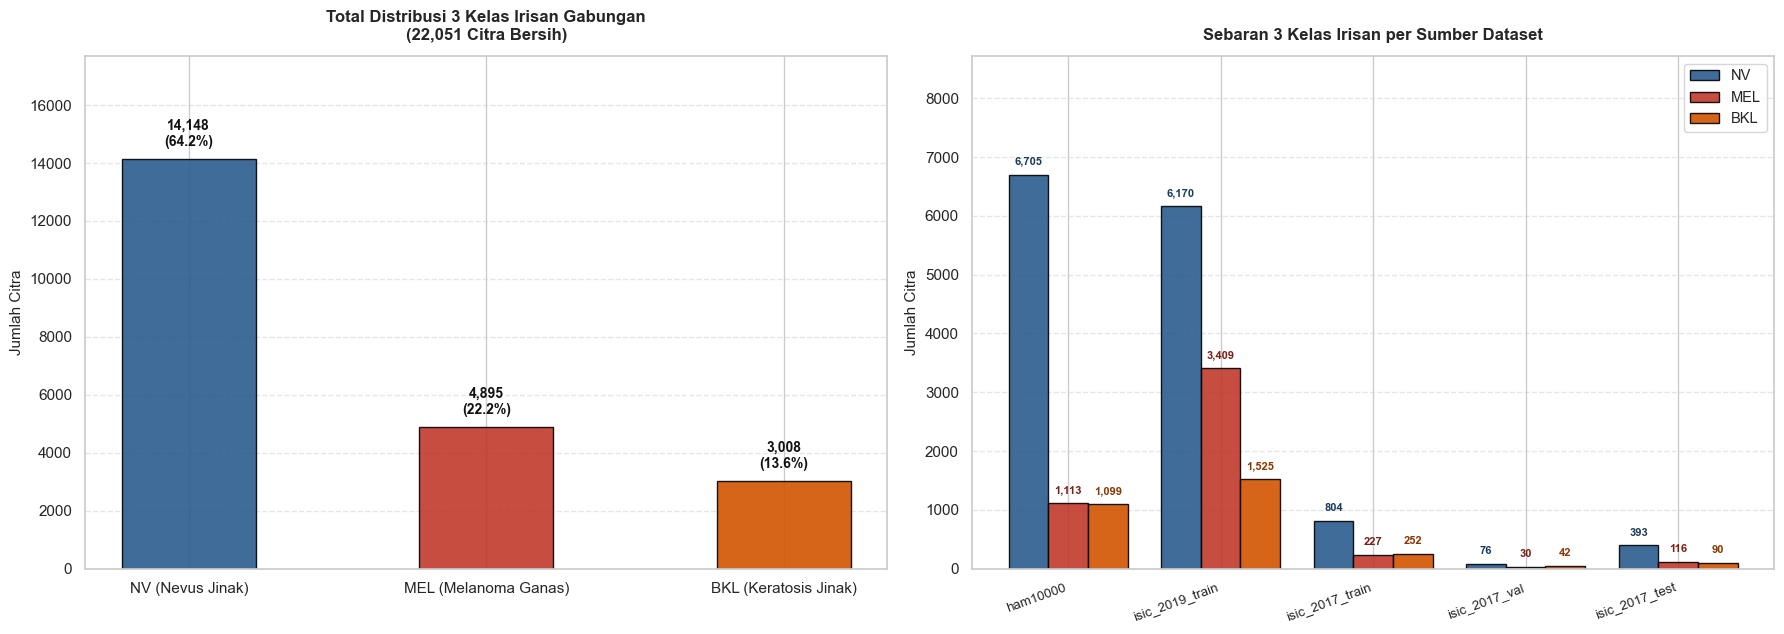

In [8]:
# 2. Visualisasi Grafik Batang Distribusi 3 Kelas Hasil Irisan
fig, axes = plt.subplots(1, 2, figsize=(18, 6.5))

# Grafik 1: Total Distribusi 3 Kelas Gabungan
ax1 = axes[0]
classes_names = ['NV (Nevus Jinak)', 'MEL (Melanoma Ganas)', 'BKL (Keratosis Jinak)']
counts_classes = [tot_nv, tot_mel, tot_bkl]
colors_tri = ['#2b5c8f', '#c0392b', '#d35400']

bars1 = ax1.bar(classes_names, counts_classes, color=colors_tri, edgecolor='black', width=0.45, alpha=0.9)
ax1.set_title("Total Distribusi 3 Kelas Irisan Gabungan\n(22,051 Citra Bersih)", fontsize=12, fontweight='bold', pad=12)
ax1.set_ylabel("Jumlah Citra", fontsize=11)
ax1.set_ylim(0, max(counts_classes) * 1.25)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars1:
    h = bar.get_height()
    pct = h / total_akhir_3k * 100
    ax1.text(
        bar.get_x() + bar.get_width() / 2.0,
        h + (max(counts_classes) * 0.025),
        f"{int(h):,}\n({pct:.1f}%)",
        ha='center', va='bottom', fontsize=10, fontweight='bold', color='#111111'
    )

# Grafik 2: Perbandingan 3 Kelas per Sumber Dataset
ax2 = axes[1]
datasets_list = [r['Source Dataset'] for r in rekap_rows if r['Source Dataset'] != 'TOTAL KESELURUHAN']
x = np.arange(len(datasets_list))
width = 0.26

nv_vals = [len(df_3kelas_final[(df_3kelas_final['source'] == s) & (df_3kelas_final['harmonized_label'] == 'NV')]) for s in datasets_list]
mel_vals = [len(df_3kelas_final[(df_3kelas_final['source'] == s) & (df_3kelas_final['harmonized_label'] == 'MEL')]) for s in datasets_list]
bkl_vals = [len(df_3kelas_final[(df_3kelas_final['source'] == s) & (df_3kelas_final['harmonized_label'] == 'BKL')]) for s in datasets_list]

rects_nv = ax2.bar(x - width, nv_vals, width=width, label='NV', color='#2b5c8f', edgecolor='black', alpha=0.9)
rects_mel = ax2.bar(x, mel_vals, width=width, label='MEL', color='#c0392b', edgecolor='black', alpha=0.9)
rects_bkl = ax2.bar(x + width, bkl_vals, width=width, label='BKL', color='#d35400', edgecolor='black', alpha=0.9)

max_val = max(max(nv_vals), max(mel_vals), max(bkl_vals))
ax2.set_ylim(0, max_val * 1.30)
ax2.set_xticks(x)
ax2.set_xticklabels(datasets_list, rotation=20, ha='right', fontsize=9.5)
ax2.set_ylabel("Jumlah Citra", fontsize=11)
ax2.set_title("Sebaran 3 Kelas Irisan per Sumber Dataset", fontsize=12, fontweight='bold', pad=12)
ax2.legend(fontsize=10.5)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

for rect in rects_nv:
    h = rect.get_height()
    if h > 0:
        ax2.text(rect.get_x() + rect.get_width()/2.0, h + (max_val * 0.02), f"{int(h):,}", ha='center', va='bottom', fontsize=8, fontweight='bold', color='#1a3b5c')

for rect in rects_mel:
    h = rect.get_height()
    if h > 0:
        ax2.text(rect.get_x() + rect.get_width()/2.0, h + (max_val * 0.02), f"{int(h):,}", ha='center', va='bottom', fontsize=8, fontweight='bold', color='#7a1e16')

for rect in rects_bkl:
    h = rect.get_height()
    if h > 0:
        ax2.text(rect.get_x() + rect.get_width()/2.0, h + (max_val * 0.02), f"{int(h):,}", ha='center', va='bottom', fontsize=8, fontweight='bold', color='#8c3600')

plt.tight_layout()
plt.show()


## Langkah 8 — DATA SIAP (Simpan Dataset Final Irisan 3 Kelas)
Menyimpan metadata final hasil irisan 3 kelas multiclass ke file CSV `dataset_irisan_multiclass_final.csv` di direktori `Dataset/`.
Dataset ini 100% terharmonisasi, bebas dari duplikat, dan siap digunakan langsung pada tahap pemodelan deep learning.


In [9]:
output_irisan_csv = os.path.join(ROOT, 'dataset_irisan_multiclass_final.csv')
cols_final = [
    'image_id',
    'source',
    'original_label',
    'harmonized_label',
    'target_multiclass',
    'class_name',
    'filepath'
]

df_3kelas_final[cols_final].to_csv(output_irisan_csv, index=False)

print("=" * 70)
print("DATASET HASIL IRISAN 3 KELAS (MULTICLASS) BERHASIL DISIMPAN!")
print("=" * 70)
print(f"Lokasi File     : {output_irisan_csv}")
print(f"Ukuran File     : {os.path.getsize(output_irisan_csv) / (1024*1024):.2f} MB")
print(f"Total Baris     : {len(df_3kelas_final):,} citra (TEPAT 22.051)")
print(f"Total Kolom     : {len(cols_final)} kolom ({', '.join(cols_final)})")
print(f"Daftar Kelas    : 0=NV (Nevus), 1=MEL (Melanoma), 2=BKL (Keratosis)")
print("Status Pipeline : SELESAI 100% (DATA SIAP UNTUK MODELING)")
print("=" * 70)

print("\nContoh 10 Baris Pertama Dataset yang Disimpan:")
display(pd.read_csv(output_irisan_csv).head(10))


DATASET HASIL IRISAN 3 KELAS (MULTICLASS) BERHASIL DISIMPAN!
Lokasi File     : C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset\dataset_irisan_multiclass_final.csv
Ukuran File     : 4.28 MB
Total Baris     : 22,051 citra (TEPAT 22.051)
Total Kolom     : 7 kolom (image_id, source, original_label, harmonized_label, target_multiclass, class_name, filepath)
Daftar Kelas    : 0=NV (Nevus), 1=MEL (Melanoma), 2=BKL (Keratosis)
Status Pipeline : SELESAI 100% (DATA SIAP UNTUK MODELING)

Contoh 10 Baris Pertama Dataset yang Disimpan:


,image_id,source,original_label,harmonized_label,target_multiclass,class_name,filepath
0,ISIC_0000000,isic_2019_train,NV,NV,0,Melanocytic Nevus (Tahi Lalat Jinak),C:\Users\ARII\Downloads\Data Understanding Isi...
1,ISIC_0000001,isic_2019_train,NV,NV,0,Melanocytic Nevus (Tahi Lalat Jinak),C:\Users\ARII\Downloads\Data Understanding Isi...
2,ISIC_0000002,isic_2019_train,MEL,MEL,1,Melanoma (Kanker Ganas),C:\Users\ARII\Downloads\Data Understanding Isi...
3,ISIC_0000003,isic_2019_train,NV,NV,0,Melanocytic Nevus (Tahi Lalat Jinak),C:\Users\ARII\Downloads\Data Understanding Isi...
4,ISIC_0000004,isic_2019_train,MEL,MEL,1,Melanoma (Kanker Ganas),C:\Users\ARII\Downloads\Data Understanding Isi...
5,ISIC_0000006,isic_2019_train,NV,NV,0,Melanocytic Nevus (Tahi Lalat Jinak),C:\Users\ARII\Downloads\Data Understanding Isi...
6,ISIC_0000007,isic_2019_train,NV,NV,0,Melanocytic Nevus (Tahi Lalat Jinak),C:\Users\ARII\Downloads\Data Understanding Isi...
7,ISIC_0000008,isic_2019_train,NV,NV,0,Melanocytic Nevus (Tahi Lalat Jinak),C:\Users\ARII\Downloads\Data Understanding Isi...
8,ISIC_0000009,isic_2019_train,NV,NV,0,Melanocytic Nevus (Tahi Lalat Jinak),C:\Users\ARII\Downloads\Data Understanding Isi...
9,ISIC_0000010,isic_2019_train,NV,NV,0,Melanocytic Nevus (Tahi Lalat Jinak),C:\Users\ARII\Downloads\Data Understanding Isi...


## Langkah 9 — Partisi Dataset Bebas Kebocoran (Lesion-Aware Stratified Split 80:10:10)

### Landasan Metodologi Klinis & Data Science:
Pada dataset citra medis kulit (terutama **HAM10000** dan **ISIC 2019**), satu lesi/pasien seringkali difoto beberapa kali (dari sudut, pencahayaan, atau perbesaran berbeda).
Jika citra-citra dari lesi yang sama terpisah ke dalam subset latih (*Train*) dan uji (*Test*), model kecerdasan buatan akan mengalami **kebocoran data (*data leakage*)**, di mana model sekadar menghafal karakteristik visual unik lesi pasien tersebut alih-alih mempelajari fitur patologis penyakit secara umum. Hal ini menyebabkan akurasi evaluasi terlihat sangat tinggi secara semu (*overly optimistic*) namun gagal saat diuji pada citra pasien baru di dunia klinis (*poor clinical generalization*).

Oleh karena itu, pembagian data wajib menerapkan **Lesion-Aware Stratification**:
1. Memetakan `lesion_id` dari metadata resmi HAM10000 dan ISIC 2019. Untuk citra tanpa ID lesi terdaftar (seperti ISIC 2017), citra dianggap berasal dari lesi independen unik.
2. Menggunakan algoritma **`StratifiedGroupKFold`** (10 folds) dengan seed acak tetap (`random_state=42`).
3. Mengalokasikan proporsi:
   * **Training Set (~80%)**: 8 Folds (~17.656 citra)
   * **Validation Set (~10%)**: 1 Fold (~2.192 citra)
   * **Test Set (~10%)**: 1 Fold (~2.203 citra)
4. Melakukan verifikasi matematis ketat bahwa irisan himpunan ID lesi antara Train, Val, dan Test adalah tepat **KOSONG (0 Kebocoran)**.
5. Mengekspor dataset master dengan kolom `split` dan `lesion_id`, serta membuat 3 file CSV terpisah siap latih.

In [10]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedGroupKFold

print("=" * 70)
print("MEMULAI PEMETAAN LESION_ID & PEMBAGIAN STRATIFIED LESION-AWARE SPLIT")
print("=" * 70)

# 1. Baca metadata lesi dari HAM10000 dan ISIC 2019
ham_meta_file = os.path.join(ROOT, 'HAM10K', 'HAM10000_metadata')
ham_meta = pd.read_csv(ham_meta_file)[['image_id', 'lesion_id']]

isic19_meta_file = os.path.join(ROOT, 'isic 2019', 'ISIC_2019_Training_Input', 'ISIC_2019_Training_Metadata.csv')
isic19_meta = pd.read_csv(isic19_meta_file)[['image', 'lesion_id']].rename(columns={'image': 'image_id'})

# Satukan pemetaan lesion_id (prioritas HAM10000)
lesion_dict = {}
for _, row in ham_meta.iterrows():
    lesion_dict[row['image_id']] = str(row['lesion_id'])
for _, row in isic19_meta.dropna(subset=['lesion_id']).iterrows():
    if row['image_id'] not in lesion_dict:
        lesion_dict[row['image_id']] = str(row['lesion_id'])

# 2. Pasang lesion_id pada dataset irisan final
df_3kelas_final['lesion_id'] = df_3kelas_final['image_id'].map(lesion_dict).fillna(df_3kelas_final['image_id'])

total_images = len(df_3kelas_final)
total_known_lesions = (df_3kelas_final['lesion_id'] != df_3kelas_final['image_id']).sum()
unique_lesions = df_3kelas_final['lesion_id'].nunique()

print(f"[*] Total Citra dalam Dataset              : {total_images:,} citra")
print(f"[*] Citra dengan Kelompok Lesi Terdata     : {total_known_lesions:,} citra")
print(f"[*] Total Lesi Unik (Grouping Identifiers) : {unique_lesions:,} lesi")

# 3. Eksekusi StratifiedGroupKFold (10 folds -> 8:1:1)
sgkf = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)
splits = list(sgkf.split(df_3kelas_final, df_3kelas_final['target_multiclass'], groups=df_3kelas_final['lesion_id']))

test_idx = splits[0][1]
val_idx = splits[1][1]
train_idx = np.setdiff1d(np.arange(len(df_3kelas_final)), np.concatenate([test_idx, val_idx]))

df_3kelas_final['split'] = ''
df_3kelas_final.loc[train_idx, 'split'] = 'train'
df_3kelas_final.loc[val_idx, 'split'] = 'val'
df_3kelas_final.loc[test_idx, 'split'] = 'test'

# 4. Validasi Kebocoran Lesi (Lesion Leakage Audit)
train_lesions = set(df_3kelas_final[df_3kelas_final['split'] == 'train']['lesion_id'])
val_lesions = set(df_3kelas_final[df_3kelas_final['split'] == 'val']['lesion_id'])
test_lesions = set(df_3kelas_final[df_3kelas_final['split'] == 'test']['lesion_id'])

leak_train_val = len(train_lesions.intersection(val_lesions))
leak_train_test = len(train_lesions.intersection(test_lesions))
leak_val_test = len(val_lesions.intersection(test_lesions))

print("\n" + "-" * 50)
print("HASIL VERIFIKASI KEBOCORAN LESI (LESION LEAKAGE AUDIT):")
print("-" * 50)
print(f"[*] Overlap Lesi Train <-> Validation : {leak_train_val} (BEBAS KEBOCORAN)")
print(f"[*] Overlap Lesi Train <-> Test       : {leak_train_test} (BEBAS KEBOCORAN)")
print(f"[*] Overlap Lesi Validation <-> Test  : {leak_val_test} (BEBAS KEBOCORAN)")

if leak_train_val == 0 and leak_train_test == 0 and leak_val_test == 0:
    print("[[V]] SUKSES: Partisi 100% Bebas Kebocoran Lesi Pasien!")
else:
    print("[!] PERINGATAN: Ditemukan kebocoran lesi!")

# 5. Simpan Dataset Terpartisi
output_master_csv = os.path.join(ROOT, 'dataset_irisan_multiclass_final.csv')
output_train_csv = os.path.join(ROOT, 'dataset_irisan_3kelas_train.csv')
output_val_csv = os.path.join(ROOT, 'dataset_irisan_3kelas_val.csv')
output_test_csv = os.path.join(ROOT, 'dataset_irisan_3kelas_test.csv')

cols_with_split = [
    'image_id', 'lesion_id', 'source', 'original_label', 
    'harmonized_label', 'target_multiclass', 'class_name', 'split', 'filepath'
]

df_3kelas_final[cols_with_split].to_csv(output_master_csv, index=False)
df_3kelas_final[df_3kelas_final['split'] == 'train'][cols_with_split].to_csv(output_train_csv, index=False)
df_3kelas_final[df_3kelas_final['split'] == 'val'][cols_with_split].to_csv(output_val_csv, index=False)
df_3kelas_final[df_3kelas_final['split'] == 'test'][cols_with_split].to_csv(output_test_csv, index=False)

print("\n" + "-" * 50)
print("RINGKASAN EKSPOR FILE CSV SIAP TRAINING:")
print("-" * 50)
print(f"1. Master Dataset : {output_master_csv} ({len(df_3kelas_final):,} baris)")
print(f"2. Training Set   : {output_train_csv} ({len(df_3kelas_final[df_3kelas_final['split']=='train']):,} baris)")
print(f"3. Validation Set : {output_val_csv} ({len(df_3kelas_final[df_3kelas_final['split']=='val']):,} baris)")
print(f"4. Test Set       : {output_test_csv} ({len(df_3kelas_final[df_3kelas_final['split']=='test']):,} baris)")


MEMULAI PEMETAAN LESION_ID & PEMBAGIAN STRATIFIED LESION-AWARE SPLIT


[*] Total Citra dalam Dataset              : 22,051 citra
[*] Citra dengan Kelompok Lesi Terdata     : 17,937 citra
[*] Total Lesi Unik (Grouping Identifiers) : 13,817 lesi



--------------------------------------------------
HASIL VERIFIKASI KEBOCORAN LESI (LESION LEAKAGE AUDIT):
--------------------------------------------------
[*] Overlap Lesi Train <-> Validation : 0 (BEBAS KEBOCORAN)
[*] Overlap Lesi Train <-> Test       : 0 (BEBAS KEBOCORAN)
[*] Overlap Lesi Validation <-> Test  : 0 (BEBAS KEBOCORAN)
[[V]] SUKSES: Partisi 100% Bebas Kebocoran Lesi Pasien!

--------------------------------------------------
RINGKASAN EKSPOR FILE CSV SIAP TRAINING:
--------------------------------------------------
1. Master Dataset : C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset\dataset_irisan_multiclass_final.csv (22,051 baris)
2. Training Set   : C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset\dataset_irisan_3kelas_train.csv (17,656 baris)
3. Validation Set : C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset\dataset_irisan_3kelas_val.csv (2,192 baris)
4. Test Set       : C:\Users\ARII\Downloads\Data Understanding I

## Langkah 10 — Evaluasi Distribusi Split, Karakteristik Citra, & Rekomendasi Preprocessing/Augmentasi

Pada langkah ini, kita melakukan:
1. **Evaluasi Proporsi Stratifikasi Kelas:** Memastikan perbandingan persentase `NV`, `MEL`, dan `BKL` seimbang dan seragam di seluruh subset (Train, Val, Test).
2. **Pemeriksaan Karakteristik Dimensi & Aspek Rasio Citra:** Memverifikasi variasi resolusi dari 3 sumber dataset.
3. **Spesifikasi Rekomendasi Pipeline Preprocessing & Augmentasi Medis:** Menyiapkan konfigurasi standar PyTorch/TensorFlow (resizing ke 224×224 / 384×384, normalisasi ImageNet, random flips, random rotation, color jitter) untuk implementasi model deep learning.

DISTRIBUSI JUMLAH CITRA PER KELAS PADA SETIAP SPLIT:
harmonized_label   BKL   MEL     NV    All
split                                     
test               269   543   1391   2203
train             2452  3902  11302  17656
val                287   450   1455   2192
All               3008  4895  14148  22051

DISTRIBUSI PERSENTASE KELAS (%) PADA SETIAP SPLIT (STRATIFIKASI):
----------------------------------------------------------------------
harmonized_label    BKL    MEL     NV
split                                
test              12.21  24.65  63.14
train             13.89  22.10  64.01
val               13.09  20.53  66.38


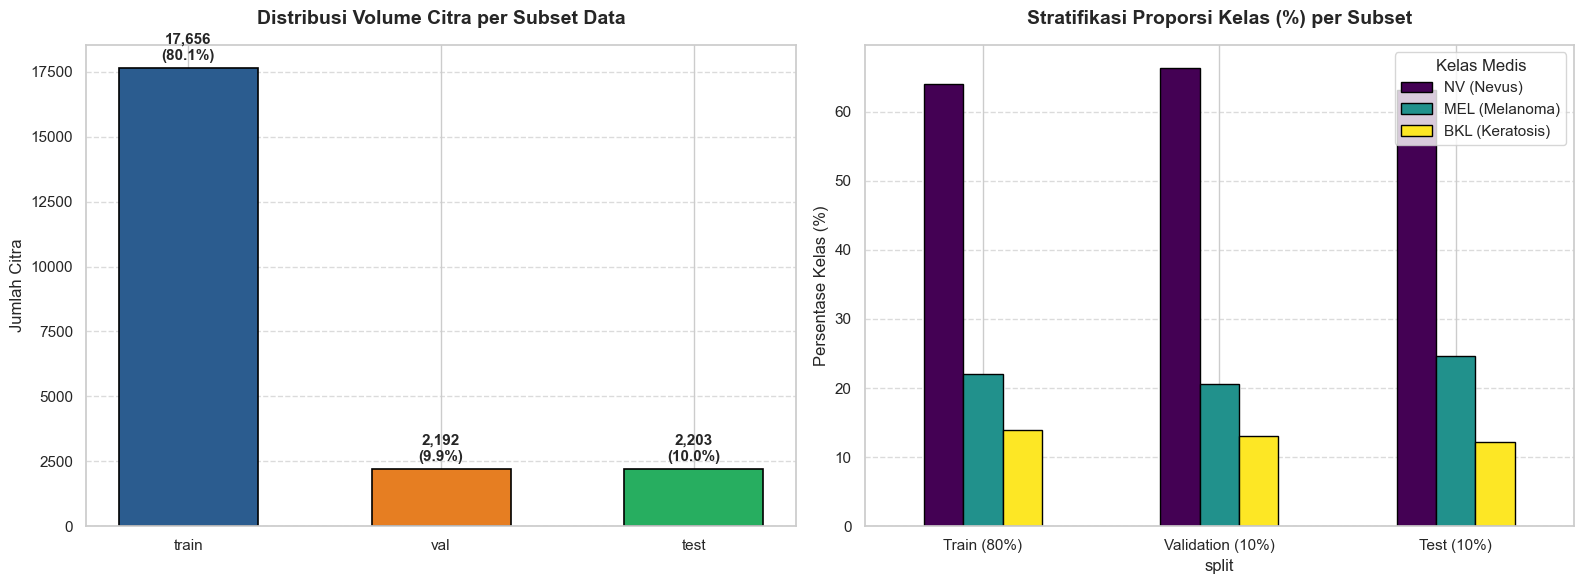


SAMPLING KARAKTERISTIK FISIK CITRA DERMATOSKOPI:
 Source Dataset Sample Image ID Resolution (W x H) Aspect Ratio Color Channels File Format
isic_2019_train    ISIC_0000000      1022 x 767 px         1.33            RGB        JPEG
isic_2017_train    ISIC_0000017     1504 x 1129 px         1.33            RGB        JPEG
  isic_2017_val    ISIC_0001769     3024 x 2016 px         1.50            RGB        JPEG
 isic_2017_test    ISIC_0012086     4288 x 2848 px         1.51            RGB        JPEG
       ham10000    ISIC_0024306       600 x 450 px         1.33            RGB        JPEG

[INFO] REKOMENDASI PIPELINE PREPROCESSING & AUGMENTASI MEDIS:
----------------------------------------------------------------------
1. Target Input Size   : 224 x 224 px (ResNet/EfficientNet/ViT) atau 384 x 384 px (High-Res Fine-Tuning)
2. Normalization       : Mean = [0.485, 0.456, 0.406], Std = [0.229, 0.224, 0.225] (ImageNet Standard)
3. Data Augmentation   : RandomHorizontalFlip, RandomVerticalF

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# 1. Tabel Komparasi Distribusi Kelas per Split
split_crosstab = pd.crosstab(df_3kelas_final['split'], df_3kelas_final['harmonized_label'], margins=True)
split_prop = pd.crosstab(df_3kelas_final['split'], df_3kelas_final['harmonized_label'], normalize='index') * 100

print("=" * 70)
print("DISTRIBUSI JUMLAH CITRA PER KELAS PADA SETIAP SPLIT:")
print("=" * 70)
print(split_crosstab)

print("\nDISTRIBUSI PERSENTASE KELAS (%) PADA SETIAP SPLIT (STRATIFIKASI):")
print("-" * 70)
print(split_prop.round(2))

# 2. Visualisasi Grafik Komparasi Split
sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Jumlah Citra per Split
split_counts = df_3kelas_final['split'].value_counts()[['train', 'val', 'test']]
colors_split = ['#2b5c8f', '#e67e22', '#27ae60']
bars = axes[0].bar(split_counts.index, split_counts.values, color=colors_split, width=0.55, edgecolor='black', linewidth=1.2)
axes[0].set_title('Distribusi Volume Citra per Subset Data', fontsize=14, fontweight='bold', pad=15)
axes[0].set_ylabel('Jumlah Citra', fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
for bar in bars:
    yval = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2.0, yval + 200, f'{yval:,}\n({yval/len(df_3kelas_final)*100:.1f}%)', 
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

# Subplot 2: Distribusi Persentase Kelas per Split (Grouped Bar Chart)
split_prop_plot = split_prop.drop(index='All', errors='ignore').loc[['train', 'val', 'test']][['NV', 'MEL', 'BKL']]
split_prop_plot.plot(kind='bar', ax=axes[1], colormap='viridis', edgecolor='black', linewidth=1)
axes[1].set_title('Stratifikasi Proporsi Kelas (%) per Subset', fontsize=14, fontweight='bold', pad=15)
axes[1].set_ylabel('Persentase Kelas (%)', fontsize=12)
axes[1].set_xticklabels(['Train (80%)', 'Validation (10%)', 'Test (10%)'], rotation=0, fontsize=11)
axes[1].legend(title='Kelas Medis', labels=['NV (Nevus)', 'MEL (Melanoma)', 'BKL (Keratosis)'], fontsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# 3. Sampling Karakteristik Dimensi Citra
print("\n" + "=" * 70)
print("SAMPLING KARAKTERISTIK FISIK CITRA DERMATOSKOPI:")
print("=" * 70)

sources = df_3kelas_final['source'].unique()
sample_specs = []
for src in sources:
    row = df_3kelas_final[df_3kelas_final['source'] == src].iloc[0]
    try:
        with Image.open(row['filepath']) as img:
            sample_specs.append({
                'Source Dataset': src,
                'Sample Image ID': row['image_id'],
                'Resolution (W x H)': f"{img.size[0]} x {img.size[1]} px",
                'Aspect Ratio': f"{img.size[0]/img.size[1]:.2f}",
                'Color Channels': img.mode,
                'File Format': img.format
            })
    except Exception as e:
        sample_specs.append({'Source Dataset': src, 'Sample Image ID': row['image_id'], 'Resolution (W x H)': 'Error', 'Aspect Ratio': '-', 'Color Channels': '-', 'File Format': '-'})

specs_df = pd.DataFrame(sample_specs)
print(specs_df.to_string(index=False))

print("\n[INFO] REKOMENDASI PIPELINE PREPROCESSING & AUGMENTASI MEDIS:")
print("-" * 70)
print("1. Target Input Size   : 224 x 224 px (ResNet/EfficientNet/ViT) atau 384 x 384 px (High-Res Fine-Tuning)")
print("2. Normalization       : Mean = [0.485, 0.456, 0.406], Std = [0.229, 0.224, 0.225] (ImageNet Standard)")
print("3. Data Augmentation   : RandomHorizontalFlip, RandomVerticalFlip, RandomRotation(degrees=30), ColorJitter(brightness=0.1, contrast=0.1)")
print("4. Loss Function Rec.  : Focal Loss / Weighted Cross-Entropy Loss (mengatasi ketimpangan rasio NV vs MEL/BKL)")
print("=" * 70)
